In [13]:
# === CELL 1: Setup ===
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from pathlib import Path
from skimage.measure import label, regionprops
from skimage.filters import threshold_otsu, gaussian
from skimage import morphology
from scipy import ndimage as ndi

plt.rcParams['figure.dpi'] = 120

NUCLEAR_CH = 0   # 405nm Binned
MCHERRY_CH = 1   # 561nm Binned
MNEON_CH   = 2   # 488nm Binned — used for cell detection

DAYS  = [8, 12, 16, 20, 25, 29, 32, 36, 39]   # all 9 imaging days
WELLS = ['E05', 'F05']

# works whether CWD is project root or notebooks/
_cwd = Path.cwd()
ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
STACK_DIR = ROOT / 'reports/260213_pilot_9day/registered_stacks'
PLOT_DIR  = ROOT / 'outputs/plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

stacks = {
    well: tifffile.imread(STACK_DIR / f'{well}_registered_common_overlap_tcyx.ome.tif')
    for well in WELLS
}

for well, arr in stacks.items():
    print(f'{well}: shape={arr.shape}  dtype={arr.dtype}  (T, C, Y, X)')


E05: shape=(9, 3, 2205, 2593)  dtype=uint16  (T, C, Y, X)
F05: shape=(9, 3, 770, 1816)  dtype=uint16  (T, C, Y, X)


## TMEM106B Neuron Alignment Pipeline

```mermaid
flowchart TD
    RAW["📁 Raw ND2 files\n(multi-tile, multi-day)"]
    CFG["⚙️ YAML config\nExperimentConfig"]

    subgraph INGEST["Ingest & QC"]
        ND2["nd2_tools.py\ninspect metadata\nbuild manifest"]
        SQC["stage_qc.py\nXY drift prefilter\n(stage coords)"]
    end

    subgraph STITCH["Stitch"]
        ST["stitch.py\ngrid-based tile stitching\n→ OME-TIFF per well per day"]
    end

    subgraph REGISTER["Two-Stage Alignment"]
        RW["register.py\nwell-level registration\nphase cross-correlation\n(nuclear / mNeonGreen ch only)"]
        RR["roi.py\nneuron-level local re-registration\nwithin cropped ROI"]
    end

    subgraph CROP["ROI Extraction"]
        RC["roi.py\ncrop ROI stack\nacross all registered days"]
    end

    subgraph QUANT["Quantification"]
        QM["mcherry_metrics.py\nbackground subtract\nforeground mask (mNeon)\npuncta detection (Otsu + morph)"]
        QP["quantify.py\ndiffuse vs puncta intensity\nrupture-like score D:P ratio"]
    end

    EX["export_zarr.py\nOME-Zarr multiscale export"]

    RAW --> ND2
    CFG --> ND2
    ND2 --> SQC
    SQC -->|"wells pass drift check"| ST
    ST --> RW
    RW -->|"registered well stack\n(T, C, Y, X)"| RC
    RC --> RR
    RR -->|"aligned ROI stack"| QM
    QM --> QP
    QP -->|"per-neuron metrics\nacross all days"| EX

    classDef module fill:#1e3a5f,color:#d0e8ff,stroke:#4a90d9
    classDef io fill:#2d4a1e,color:#c8f0a0,stroke:#5cb85c
    classDef cfg fill:#4a3000,color:#ffd97d,stroke:#f0a500
    class ND2,SQC,ST,RW,RR,RC,QM,QP,EX module
    class RAW io
    class CFG cfg
```

**Key constraint:** mCherry channel is **never** used for registration — it changes with biology.
Well rows E/I/M (mCherry only) and F/J/N (TMEM106B + mCherry) are valid for quantification; C/D/G/H/K/L are not.

In [14]:
# === CELL 2: Channel Overview ===
CH_NAMES = {NUCLEAR_CH: 'Nuclear 405nm', MCHERRY_CH: 'mCherry 561nm', MNEON_CH: 'mNeonGreen 488nm'}
T_IDX = 0  # day 8

_s = stacks[WELLS[0]][T_IDX, NUCLEAR_CH]
_asp = _s.shape[0] / _s.shape[1]
fig, axes = plt.subplots(len(WELLS), len(CH_NAMES), figsize=(15, 5 * _asp * len(WELLS)))

for row, well in enumerate(WELLS):
    for col, ch in enumerate(sorted(CH_NAMES)):
        img = stacks[well][T_IDX, ch]
        lo, hi = np.percentile(img, [1, 99])
        ax = axes[row, col]
        ax.imshow(img, cmap='gray', vmin=lo, vmax=hi, interpolation='nearest')
        ax.set_title(f'{well} — {CH_NAMES[ch]}\nday {DAYS[T_IDX]}', fontsize=9, pad=2)
        ax.axis('off')

fig.suptitle('Channel overview — day 8 (time index 0)', fontsize=12, y=1.0)
fig.subplots_adjust(left=0.0, right=1.0, top=0.985, bottom=0.0, hspace=0.01, wspace=0.01)
fig.savefig(PLOT_DIR / 'channel_overview_day8.png', dpi=150, bbox_inches='tight')
plt.show()


KeyboardInterrupt: 

In [ ]:
# === CELL 3a: Segmentation functions ===

def segment_cells(frame, sigma=3, min_area=500, max_area=200_000):
    """Coarse Otsu segmentation — detects large blobs/clusters."""
    img = np.clip(frame.astype(float) - np.percentile(frame, 10), 0, None)
    blurred = gaussian(img, sigma=sigma)
    thresh = threshold_otsu(blurred)
    mask = blurred > thresh
    mask = ndi.binary_fill_holes(mask)
    mask = morphology.remove_small_objects(mask, max_size=min_area - 1)
    labeled = label(mask)
    props = [p for p in regionprops(labeled) if p.area <= max_area]
    return labeled, props


def segment_tuned_otsu(frame, sigma=1, min_area=50, max_area=200_000, bg_pct=5):
    """Tighter Otsu — lower background percentile and min_area to detect individual cells."""
    img = np.clip(frame.astype(float) - np.percentile(frame, bg_pct), 0, None)
    blurred = gaussian(img, sigma=sigma)
    thresh = threshold_otsu(blurred)
    mask = blurred > thresh
    mask = ndi.binary_fill_holes(mask)
    mask = morphology.remove_small_objects(mask, max_size=min_area - 1)
    labeled = label(mask)
    props = [p for p in regionprops(labeled) if p.area <= max_area]
    keep = {p.label for p in props}
    clean = np.where(np.isin(labeled, list(keep)), labeled, 0)
    return clean, props


def overlay_labels(img, labeled, alpha=0.4):
    """Return float RGB: gray image with each cell ID a distinct hue."""
    lo, hi = np.percentile(img, 1), np.percentile(img, 99)
    gray = np.clip((img.astype(float) - lo) / (hi - lo + 1e-9), 0, 1)
    rgb = np.stack([gray, gray, gray], axis=-1)
    n = int(labeled.max())
    if n > 0:
        cmap = plt.colormaps["tab20"]
        lut = np.zeros((n + 1, 3), dtype=np.float32)
        lut[1:] = np.array([cmap(i % 20)[:3] for i in range(n)])
        color_img = lut[labeled]
        fg = labeled > 0
        rgb[fg] = (1 - alpha) * rgb[fg] + alpha * color_img[fg]
    return np.clip(rgb, 0, 1)


E05 day 8: 39 cells detected
F05 day 8: 9 cells detected


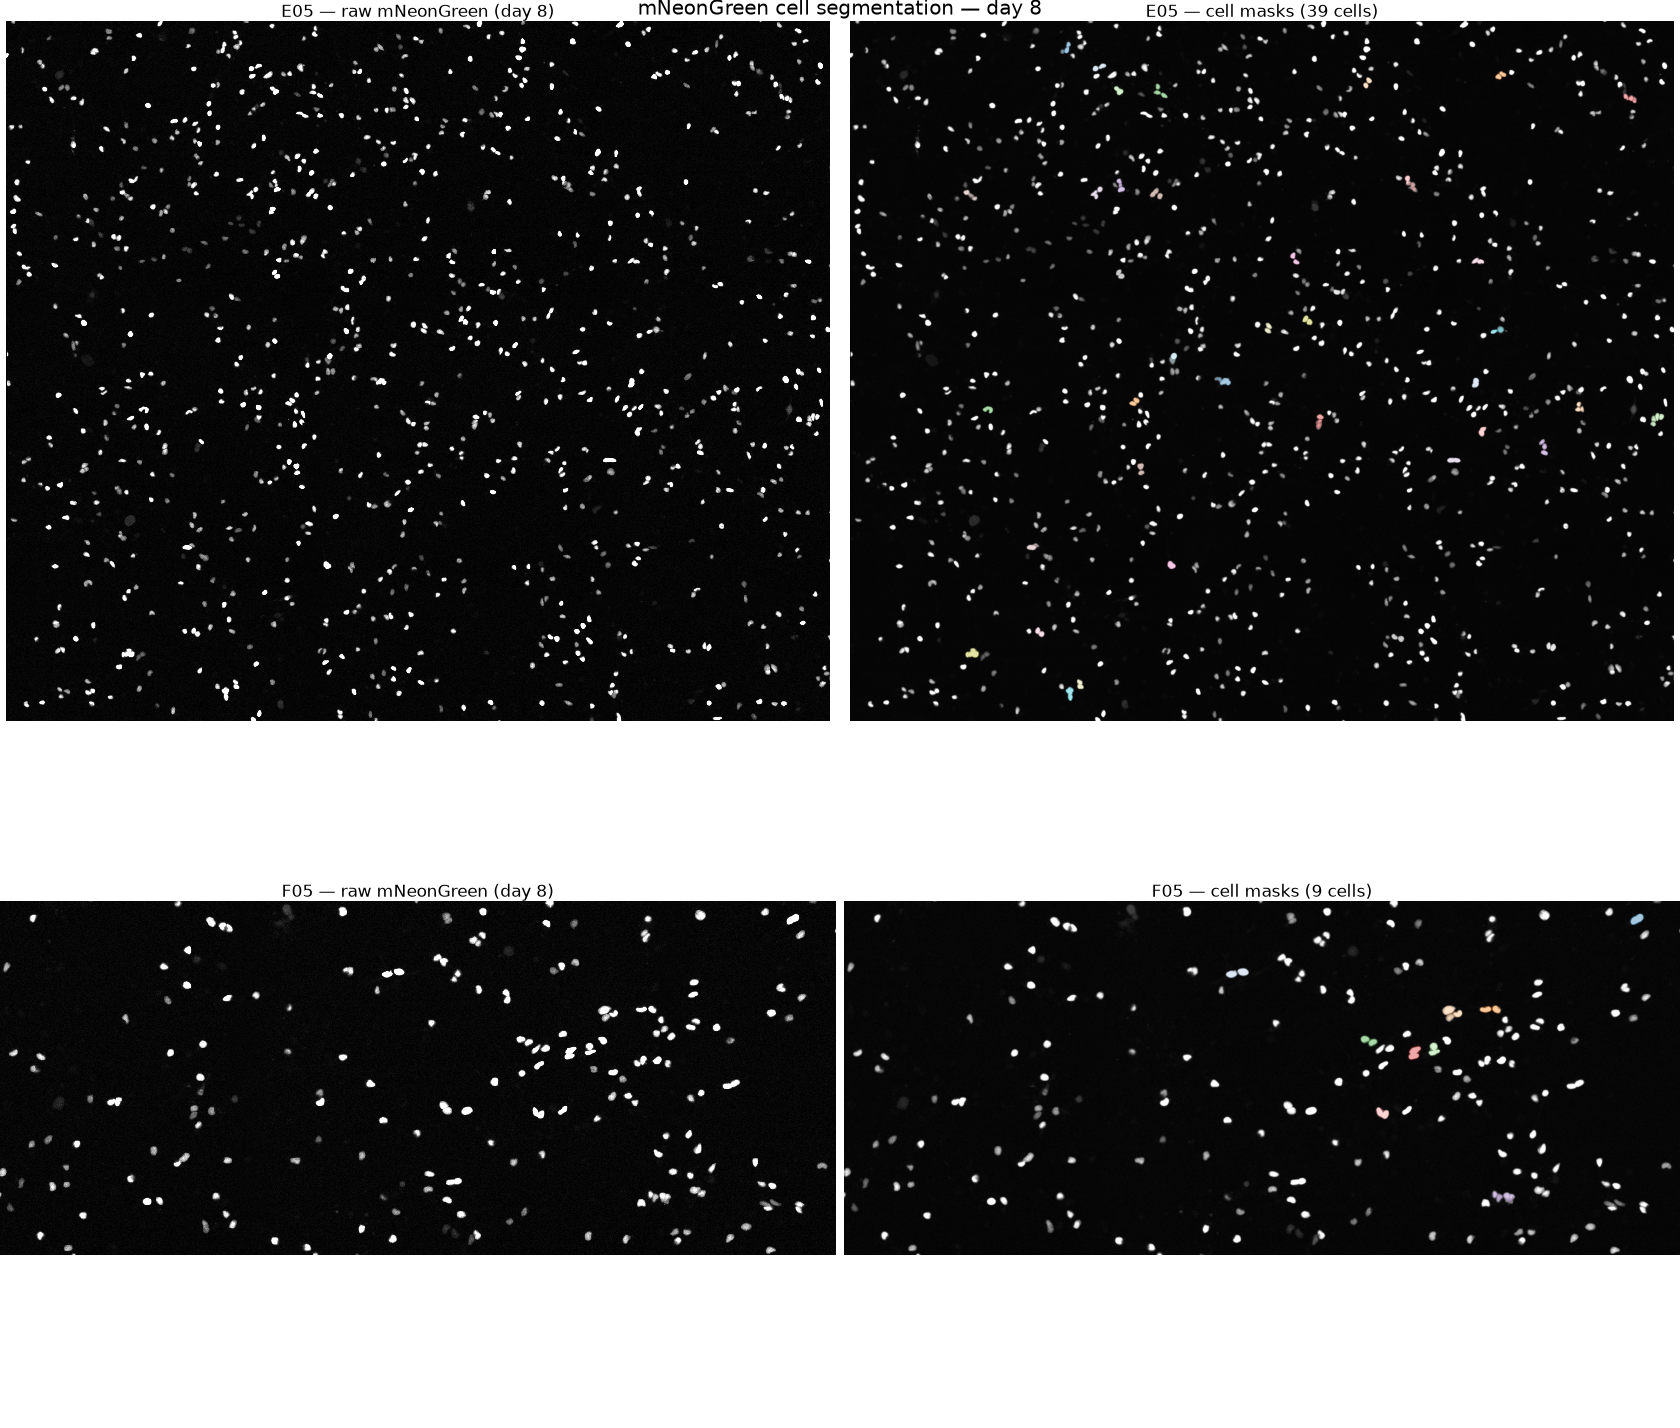

In [ ]:
# === CELL 3b: Show segmentation at day 8 ===

_s = stacks[WELLS[0]][0, MNEON_CH]
_asp = _s.shape[0] / _s.shape[1]
fig, axes = plt.subplots(2, 2, figsize=(14, 7 * _asp * 2))

for row, well in enumerate(WELLS):
    frame = stacks[well][0, MNEON_CH]
    labeled, props = segment_cells(frame)
    print(f"{well} day {DAYS[0]}: {len(props)} cells detected")

    lo, hi = np.percentile(frame, 1), np.percentile(frame, 99)
    axes[row, 0].imshow(frame, cmap="gray", vmin=lo, vmax=hi, interpolation="nearest")
    axes[row, 0].set_title(f"{well} — raw mNeonGreen (day {DAYS[0]})", fontsize=10, pad=2)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(overlay_labels(frame, labeled))
    axes[row, 1].set_title(f"{well} — cell masks ({len(props)} cells)", fontsize=10, pad=2)
    axes[row, 1].axis("off")

plt.suptitle("mNeonGreen cell segmentation — day 8", fontsize=12, y=1.0)
fig.subplots_adjust(left=0.0, right=1.0, top=0.985, bottom=0.0, hspace=0.01, wspace=0.01)
fig.savefig(PLOT_DIR / 'segmentation_day8.png', dpi=150, bbox_inches='tight')
plt.show()


Well    Day 8    Day 12   Day 16   Day 20   Day 25   Day 29   Day 32   Day 36   Day 39   
-----------------------------------------------------------------------------------------
E05     39       15       17       13       21       25       20       16       22       
F05     9        3        1        3        0        3        2        4        3        


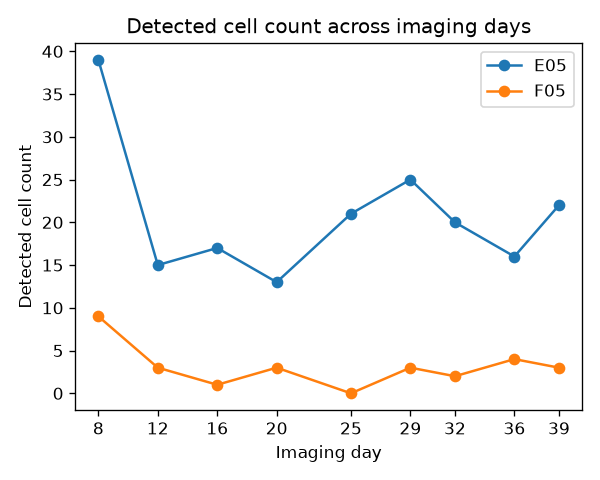

In [ ]:
# === CELL 3c: Cell count across days ===

counts = {}
print(f"{'Well':<8}" + "".join(f"Day {d:<5}" for d in DAYS))
print("-" * (8 + 9 * len(DAYS)))

for well in WELLS:
    well_counts = []
    for t in range(len(DAYS)):
        _, props = segment_cells(stacks[well][t, MNEON_CH])
        well_counts.append(len(props))
    counts[well] = well_counts
    print(f"{well:<8}" + "".join(f"{c:<9}" for c in well_counts))

fig, ax = plt.subplots(figsize=(5, 4))
for well, c in counts.items():
    ax.plot(DAYS, c, marker="o", label=well)
ax.set_xlabel("Imaging day")
ax.set_ylabel("Detected cell count")
ax.set_title("Detected cell count across imaging days")
ax.set_xticks(DAYS)
ax.legend()
plt.tight_layout()
fig.savefig(PLOT_DIR / 'cell_count_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# === CELL 4: Area-based cell tracking across all days ===

from tmem_align.analysis.mcherry_metrics import background_subtract, foreground_mask, detect_puncta

EXAMPLE_WELL = 'E05'
PAD = 20
H, W = stacks[EXAMPLE_WELL].shape[2], stacks[EXAMPLE_WELL].shape[3]
RNG_SEED = 42

_, ref_props = segment_tuned_otsu(stacks[EXAMPLE_WELL][0, MNEON_CH])
rng = np.random.default_rng(RNG_SEED)
idx = rng.choice(len(ref_props), size=min(8, len(ref_props)), replace=False)
sampled8 = [ref_props[i] for i in idx]

cell_bboxes = []
for cell in sampled8:
    r0, c0, r1, c1 = cell.bbox
    cell_bboxes.append((
        max(0, r0 - PAD), min(H, r1 + PAD),
        max(0, c0 - PAD), min(W, c1 + PAD),
    ))

n_t = len(DAYS)
n_cols = 2 * n_t

_yr0, _yr1, _xc0, _xc1 = cell_bboxes[0]
_s = stacks[EXAMPLE_WELL][0, MNEON_CH, _yr0:_yr1, _xc0:_xc1]
_asp = _s.shape[0] / _s.shape[1]

fig, axes = plt.subplots(8, n_cols, figsize=(2 * n_cols, 2 * _asp * 8))

for row_i, (cell, (yr0, yr1, xc0, xc1)) in enumerate(zip(sampled8, cell_bboxes)):
    mneon_crops   = [stacks[EXAMPLE_WELL][t, MNEON_CH,   yr0:yr1, xc0:xc1] for t in range(n_t)]
    mcherry_crops = [stacks[EXAMPLE_WELL][t, MCHERRY_CH, yr0:yr1, xc0:xc1] for t in range(n_t)]

    mneon_lo,   mneon_hi   = np.percentile(np.concatenate([c.ravel() for c in mneon_crops]),   [1, 99])
    mcherry_lo, mcherry_hi = np.percentile(np.concatenate([c.ravel() for c in mcherry_crops]), [1, 99])

    for t_i in range(n_t):
        axes[row_i, t_i * 2].imshow(
            mneon_crops[t_i], cmap='gray', vmin=mneon_lo, vmax=mneon_hi, interpolation='nearest'
        )
        axes[row_i, t_i * 2].axis('off')
        axes[row_i, t_i * 2 + 1].imshow(
            mcherry_crops[t_i], cmap='magma', vmin=mcherry_lo, vmax=mcherry_hi, interpolation='nearest'
        )
        axes[row_i, t_i * 2 + 1].axis('off')

    axes[row_i, 0].text(0.02, 0.5, f'Cell {row_i + 1}\n{cell.area}px',
                        transform=axes[row_i, 0].transAxes,
                        fontsize=6, color='white', va='center', ha='left')

for t_i in range(n_t):
    axes[0, t_i * 2].set_title(f'D{DAYS[t_i]}\nmNeon', fontsize=7, pad=2)
    axes[0, t_i * 2 + 1].set_title(f'D{DAYS[t_i]}\nmCherry', fontsize=7, pad=2)

fig.suptitle(f'8 randomly sampled cells (seed={RNG_SEED}) across all {n_t} days — E05', fontsize=12, y=1.0)
fig.subplots_adjust(left=0.0, right=1.0, top=0.985, bottom=0.0, hspace=0.01, wspace=0.01)
fig.savefig(PLOT_DIR / 'random_cells_all_days.png', dpi=150, bbox_inches='tight')
plt.show()


NameError: name 'segment_tuned_otsu' is not defined

In [ ]:
# === CELL 5: mCherry mask overlays per cell, all days ===

def _make_overlay(corrected: np.ndarray, fg: np.ndarray, puncta: np.ndarray) -> np.ndarray:
    """Gray mCherry image with green=diffuse, red=puncta tints."""
    pos = corrected[corrected > 0]
    hi = float(np.percentile(pos, 99)) if pos.size else 1.0
    gray = np.clip(corrected / (hi + 1e-9), 0, 1).astype(np.float32)
    rgb = np.stack([gray, gray, gray], axis=-1)

    diffuse = fg & ~puncta
    if diffuse.any():
        rgb[diffuse, 0] = gray[diffuse] * 0.25
        rgb[diffuse, 1] = np.clip(gray[diffuse] + 0.35, 0, 1)
        rgb[diffuse, 2] = gray[diffuse] * 0.25

    if puncta.any():
        rgb[puncta, 0] = np.clip(gray[puncta] + 0.45, 0, 1)
        rgb[puncta, 1] = gray[puncta] * 0.15
        rgb[puncta, 2] = gray[puncta] * 0.15

    return rgb


n_t = len(DAYS)
_yr0, _yr1, _xc0, _xc1 = cell_bboxes[0]
_s = stacks[EXAMPLE_WELL][0, MCHERRY_CH, _yr0:_yr1, _xc0:_xc1]
_asp = _s.shape[0] / _s.shape[1]

N_CELL_ROWS = len(cell_bboxes)
n_rows = 1 + N_CELL_ROWS
fig, axes = plt.subplots(n_rows, n_t, figsize=(2 * n_t, 2 * _asp * n_rows))

# --- Row 0: mNeonGreen reference (Cell 1 crop) across all days ---
yr0, yr1, xc0, xc1 = cell_bboxes[0]
mneon_ref = [stacks[EXAMPLE_WELL][t, MNEON_CH, yr0:yr1, xc0:xc1] for t in range(n_t)]
mn_lo, mn_hi = np.percentile(np.concatenate([c.ravel() for c in mneon_ref]), [1, 99])
for t_i in range(n_t):
    ax = axes[0, t_i]
    ax.imshow(mneon_ref[t_i], cmap='gray', vmin=mn_lo, vmax=mn_hi, interpolation='nearest')
    ax.axis('off')
    ax.set_title(f'Day {DAYS[t_i]}', fontsize=7, pad=2)
axes[0, 0].text(0.02, 0.5, 'mNeon\nCell 1', transform=axes[0, 0].transAxes,
                fontsize=6, color='white', va='center', ha='left')

# --- Rows 1–8: mCherry overlays per cell ---
for row_i, (yr0, yr1, xc0, xc1) in enumerate(cell_bboxes):
    for t_i in range(n_t):
        mcherry_crop = stacks[EXAMPLE_WELL][t_i, MCHERRY_CH, yr0:yr1, xc0:xc1]
        mneon_crop   = stacks[EXAMPLE_WELL][t_i, MNEON_CH,   yr0:yr1, xc0:xc1]

        corrected = background_subtract(mcherry_crop)
        fg        = foreground_mask(mneon_crop)
        puncta    = detect_puncta(corrected, fg)

        overlay = _make_overlay(corrected, fg, puncta)

        diffuse_int  = float(corrected[fg & ~puncta].sum())
        punctate_int = float(corrected[puncta].sum())
        dp = diffuse_int / (punctate_int + 1e-9)

        ax = axes[row_i + 1, t_i]
        ax.imshow(overlay, interpolation='nearest')
        ax.axis('off')
        ax.text(2, overlay.shape[0] - 3, f'D:P={dp:.2f}',
                color='white', fontsize=6, va='bottom')

    axes[row_i + 1, 0].text(0.02, 0.5, f'Cell {row_i + 1}',
                             transform=axes[row_i + 1, 0].transAxes,
                             fontsize=6, color='white', va='center', ha='left')

fig.suptitle('mCherry mask overlays per cell — E05 (green=diffuse, red=puncta)', fontsize=9, y=1.0)
fig.subplots_adjust(left=0.0, right=1.0, top=0.985, bottom=0.0, hspace=0.01, wspace=0.01)
fig.savefig(PLOT_DIR / 'mcherry_overlays_per_cell.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Segmentation Method Comparison

The current `segment_cells()` uses global Otsu on mNeonGreen with sigma=3 and min_area=500, detecting only ~23-47 large blobs. There are hundreds of visible neurons. Below we test multiple approaches and compare cell counts.

In [ ]:
# === Segmentation helpers: all methods + comparison figure generator ===

from skimage.filters import threshold_local
from skimage.feature import blob_dog, blob_log
from skimage.transform import downscale_local_mean
from scipy.spatial import KDTree
from concurrent.futures import ThreadPoolExecutor

FIG_DIR = ROOT / 'reports/260213_pilot_reproduced/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

_DS = 2  # 2× downsample factor for blob detection (4× fewer pixels → ~4× faster)


def _clip_gray(img):
    """Percentile-clip to [0,1] float for display."""
    lo, hi = np.percentile(img, [1, 99])
    return np.clip((img.astype(float) - lo) / (hi - lo + 1e-9), 0, 1)


def _overlay_mask(img, labeled, alpha=0.4):
    """Gray + colored label overlay, returns float RGB."""
    gray = _clip_gray(img)
    rgb = np.stack([gray, gray, gray], axis=-1)
    n = int(labeled.max())
    if n > 0:
        cmap = plt.colormaps['tab20']
        lut = np.zeros((n + 1, 3), dtype=np.float32)
        lut[1:] = np.array([cmap(i % 20)[:3] for i in range(n)])
        color_img = lut[labeled]  # vectorized: one fancy-index instead of n array scans
        fg = labeled > 0
        rgb[fg] = (1 - alpha) * rgb[fg] + alpha * color_img[fg]
    return np.clip(rgb, 0, 1)


# --- Method 1: Tuned Otsu (lower percentile, smaller sigma & min_area) ---
def segment_tuned_otsu(frame, sigma=1, min_area=50, max_area=200_000, bg_pct=5):
    img = np.clip(frame.astype(float) - np.percentile(frame, bg_pct), 0, None)
    blurred = gaussian(img, sigma=sigma)
    thresh = threshold_otsu(blurred)
    mask = blurred > thresh
    mask = ndi.binary_fill_holes(mask)
    mask = morphology.remove_small_objects(mask, max_size=min_area - 1)
    labeled = label(mask)
    props = [p for p in regionprops(labeled) if p.area <= max_area]
    keep = {p.label for p in props}
    clean = np.where(np.isin(labeled, list(keep)), labeled, 0)
    return clean, props


# --- Method 2: DoG blob detection (runs on 2× downsampled image) ---
def segment_dog(frame, min_sigma=3, max_sigma=15, threshold_rel=0.1):
    img = downscale_local_mean(_clip_gray(frame), (_DS, _DS))
    blobs = blob_dog(img, min_sigma=min_sigma / _DS, max_sigma=max_sigma / _DS,
                     threshold=threshold_rel)
    if len(blobs) > 0:
        blobs[:, :2] *= _DS
        blobs[:, 2] = blobs[:, 2] * _DS * np.sqrt(2)
    return blobs


# --- Method 3: LoG blob detection (runs on 2× downsampled image) ---
def segment_log(frame, min_sigma=3, max_sigma=15, num_sigma=10, threshold_rel=0.05):
    img = downscale_local_mean(_clip_gray(frame), (_DS, _DS))
    blobs = blob_log(img, min_sigma=min_sigma / _DS, max_sigma=max_sigma / _DS,
                     num_sigma=num_sigma, threshold=threshold_rel)
    if len(blobs) > 0:
        blobs[:, :2] *= _DS
        blobs[:, 2] = blobs[:, 2] * _DS * np.sqrt(2)
    return blobs


# --- Method 4: Percentile threshold + morphological cleanup ---
def segment_percentile(frame, pct_threshold=85, sigma=1, min_area=50, max_area=200_000):
    img = gaussian(frame.astype(float), sigma=sigma)
    thresh = np.percentile(img, pct_threshold)
    mask = img > thresh
    mask = morphology.opening(mask, morphology.disk(2))
    mask = morphology.closing(mask, morphology.disk(1))
    mask = ndi.binary_fill_holes(mask)
    mask = morphology.remove_small_objects(mask, max_size=min_area - 1)
    labeled = label(mask)
    props = [p for p in regionprops(labeled) if min_area <= p.area <= max_area]
    keep = {p.label for p in props}
    clean = np.where(np.isin(labeled, list(keep)), labeled, 0)
    return clean, props


print("Segmentation methods defined.")


Segmentation methods defined.


In [ ]:
# === Segmentation method comparison — 4 methods, single figure ===
from skimage.draw import disk as skdisk

frame_e05 = stacks['E05'][0, MNEON_CH]

labeled_to,  props_to  = segment_tuned_otsu(frame_e05)
blobs_dog               = segment_dog(frame_e05)
blobs_log_data          = segment_log(frame_e05)
labeled_pct, props_pct  = segment_percentile(frame_e05)
n_to, n_dog, n_log, n_pct = len(props_to), len(blobs_dog), len(blobs_log_data), len(props_pct)
print(f"Tuned Otsu: {n_to} | DoG: {n_dog} | LoG: {n_log} | Percentile: {n_pct}")

raw_gray = _clip_gray(frame_e05)

def _blob_map(frame, blobs):
    """White discs on black — fast via skimage.draw.disk."""
    dmap = np.zeros(frame.shape, dtype=np.uint8)
    for blob in blobs:
        rr, cc = skdisk((int(blob[0]), int(blob[1])), max(int(blob[2]), 2), shape=frame.shape)
        dmap[rr, cc] = 255
    return dmap

_asp = frame_e05.shape[0] / frame_e05.shape[1]
fig, axes = plt.subplots(4, 3, figsize=(18, 6 * _asp * 4))

COL_HEADERS = [
    'Raw mNeonGreen (E05 day 8)',
    f'binary mask',
    f'overlay',
]
METHOD_LABELS = [
    f'Tuned Otsu ({n_to} cells)',
    f'DoG ({n_dog} blobs)',
    f'LoG ({n_log} blobs)',
    f'Percentile p85 ({n_pct} cells)',
]

# Images
axes[0, 0].imshow(raw_gray,              cmap='gray', interpolation='nearest')
axes[0, 1].imshow(labeled_to > 0,        cmap='gray', interpolation='nearest')
axes[0, 2].imshow(_overlay_mask(frame_e05, labeled_to, alpha=0.7))

axes[1, 0].imshow(raw_gray,              cmap='gray', interpolation='nearest')
axes[1, 1].imshow(_blob_map(frame_e05, blobs_dog),    cmap='gray', interpolation='nearest')
axes[1, 2].imshow(raw_gray,              cmap='gray', interpolation='nearest')
for blob in blobs_dog:
    axes[1, 2].add_patch(plt.Circle((blob[1], blob[0]), blob[2], color='lime', lw=0.5, fill=False))

axes[2, 0].imshow(raw_gray,              cmap='gray', interpolation='nearest')
axes[2, 1].imshow(_blob_map(frame_e05, blobs_log_data), cmap='gray', interpolation='nearest')
axes[2, 2].imshow(raw_gray,              cmap='gray', interpolation='nearest')
for blob in blobs_log_data:
    axes[2, 2].add_patch(plt.Circle((blob[1], blob[0]), blob[2], color='cyan', lw=0.5, fill=False))

axes[3, 0].imshow(raw_gray,              cmap='gray', interpolation='nearest')
axes[3, 1].imshow(labeled_pct > 0,       cmap='gray', interpolation='nearest')
axes[3, 2].imshow(_overlay_mask(frame_e05, labeled_pct))

for ax in axes.flat:
    ax.axis('off')

# Column headers — top row only, inside axes
_hdr_kw = dict(fontsize=9, color='white', va='top', ha='center',
               bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.5, ec='none'))
for col, hdr in enumerate(COL_HEADERS):
    axes[0, col].text(0.5, 0.99, hdr, transform=axes[0, col].transAxes, **_hdr_kw)

# Method labels — left column, every row
_lbl_kw = dict(fontsize=8, color='white', va='top', ha='left',
               bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.4, ec='none'))
for row_i, lbl in enumerate(METHOD_LABELS):
    axes[row_i, 0].text(0.02, 0.97, lbl, transform=axes[row_i, 0].transAxes, **_lbl_kw)

fig.suptitle('Segmentation method comparison — E05 day 8', fontsize=14, y=1.0)
fig.subplots_adjust(left=0.0, right=1.0, top=0.985, bottom=0.0, hspace=0.01, wspace=0.01)
fig.savefig(FIG_DIR  / 'segmentation_comparison_all_methods.png', dpi=150, bbox_inches='tight')
fig.savefig(PLOT_DIR / 'segmentation_comparison_all_methods.png', dpi=150, bbox_inches='tight')
plt.show()


### Cross-Day Cell Count Comparison (all methods, E05)

In [ ]:
# === Cross-day cell count comparison: all methods on E05 ===
# Original Otsu counts reused from cell 3c (counts['E05']) — no recomputation needed.

def _count_day(t):
    frame = stacks['E05'][t, MNEON_CH]
    return {
        'Tuned Otsu':      len(segment_tuned_otsu(frame)[1]),
        'DoG':             len(segment_dog(frame)),
        'LoG':             len(segment_log(frame)),
        'Percentile (p85)': len(segment_percentile(frame)[1]),
    }

with ThreadPoolExecutor() as pool:
    _day_results = list(pool.map(_count_day, range(len(DAYS))))

method_counts = {
    'Original Otsu':    counts['E05'],  # from cell 3c
    'Tuned Otsu':       [d['Tuned Otsu']       for d in _day_results],
    'DoG':              [d['DoG']              for d in _day_results],
    'LoG':              [d['LoG']              for d in _day_results],
    'Percentile (p85)': [d['Percentile (p85)'] for d in _day_results],
}

header = f"{'Method':<20}" + "".join(f"Day {d:<6}" for d in DAYS)
print(header)
print("-" * len(header))
for method, mc in method_counts.items():
    print(f"{method:<20}" + "".join(f"{c:<9}" for c in mc))

fig, ax = plt.subplots(figsize=(8, 5))
markers = ['o', 's', '^', 'D', 'v']
for i, (method, mc) in enumerate(method_counts.items()):
    ax.plot(DAYS, mc, marker=markers[i % len(markers)], label=method, linewidth=1.5)

ax.set_xlabel('Imaging day')
ax.set_ylabel('Detected cell count')
ax.set_title('Cell count by segmentation method — E05 across days')
ax.set_xticks(DAYS)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR  / 'segmentation_comparison_crossday.png', dpi=150, bbox_inches='tight')
fig.savefig(PLOT_DIR / 'segmentation_comparison_crossday.png', dpi=150, bbox_inches='tight')
plt.show()


### Centroid-Based Cell Tracking (best method, KDTree matching)

Segments at each timepoint using LoG (highest cell count at day 8 among blob-based methods) and matches centroids to the day-8 reference via KDTree nearest-neighbor (max distance = 50 px).

In [ ]:
# === Centroid-based cell tracking across days — LoG, all 9 timepoints ===
# LoG chosen: ~7% more detections than DoG, same biologically plausible cross-day decline.

all_blobs_log = [segment_log(stacks['E05'][t, MNEON_CH]) for t in range(len(DAYS))]
for t, blobs in enumerate(all_blobs_log):
    print(f"LoG day {DAYS[t]}: {len(blobs)} cells")

ref_blobs     = all_blobs_log[0]
ref_centroids = ref_blobs[:, :2]

MAX_DIST = 50
tracked_log = {i: [ref_blobs[i]] for i in range(len(ref_blobs))}

for t in range(1, len(DAYS)):
    blobs_t = all_blobs_log[t]
    if len(blobs_t) == 0:
        for i in range(len(ref_blobs)):
            tracked_log[i].append(None)
        continue
    tree = KDTree(blobs_t[:, :2])
    dists, idxs = tree.query(ref_centroids)
    for i in range(len(ref_blobs)):
        tracked_log[i].append(blobs_t[idxs[i]] if dists[i] <= MAX_DIST else None)

full_track_log = [i for i, m in tracked_log.items() if all(x is not None for x in m)]
print(f"Tracked across all {len(DAYS)} days: {len(full_track_log)} / {len(ref_blobs)}")

# 8 rows (one crop per row), but crosshairs drawn for top 20 tracked cells
top8_log  = sorted(full_track_log, key=lambda i: tracked_log[i][0][2], reverse=True)[:8]
top20_log = sorted(full_track_log, key=lambda i: tracked_log[i][0][2], reverse=True)[:20]

HALF  = 200
H_e, W_e = stacks['E05'].shape[2], stacks['E05'].shape[3]
n_cols = 2 * len(DAYS)

# tab20 gives 20 visually distinct colors; keyed by cell index in top20_log
cell_colors = {ref_i: plt.cm.tab20(j / max(len(top20_log) - 1, 1))
               for j, ref_i in enumerate(top20_log)}

_b0r = tracked_log[top8_log[0]][0]
_y0r, _x0r = int(_b0r[0]), int(_b0r[1])
_s = stacks['E05'][0, MNEON_CH,
     max(0, _y0r - HALF):min(H_e, _y0r + HALF),
     max(0, _x0r - HALF):min(W_e, _x0r + HALF)]
_asp = _s.shape[0] / _s.shape[1]

fig, axes = plt.subplots(len(top8_log), n_cols, figsize=(2 * n_cols, 2 * _asp * len(top8_log)))
if len(top8_log) == 1:
    axes = axes[np.newaxis, :]

for row_i, ref_i in enumerate(top8_log):
    b0 = tracked_log[ref_i][0]
    y0, x0 = int(b0[0]), int(b0[1])
    yr0 = max(0, y0 - HALF);  yr1 = min(H_e, y0 + HALF)
    xc0 = max(0, x0 - HALF);  xc1 = min(W_e, x0 + HALF)

    mneon_crops   = [stacks['E05'][t, MNEON_CH,   yr0:yr1, xc0:xc1] for t in range(len(DAYS))]
    mcherry_crops = [stacks['E05'][t, MCHERRY_CH, yr0:yr1, xc0:xc1] for t in range(len(DAYS))]
    mneon_lo,   mneon_hi   = np.percentile(np.concatenate([c.ravel() for c in mneon_crops]),   [1, 99])
    mcherry_lo, mcherry_hi = np.percentile(np.concatenate([c.ravel() for c in mcherry_crops]), [1, 99])

    for t_i in range(len(DAYS)):
        ax_mn = axes[row_i, t_i * 2]
        ax_mn.imshow(mneon_crops[t_i], cmap='gray', vmin=mneon_lo, vmax=mneon_hi, interpolation='nearest')
        ax_mn.axis('off')

        ax_mc = axes[row_i, t_i * 2 + 1]
        ax_mc.imshow(mcherry_crops[t_i], cmap='magma', vmin=mcherry_lo, vmax=mcherry_hi, interpolation='nearest')
        ax_mc.axis('off')

        # crosshairs for all 20 tracked cells visible in this crop
        for other_ref_i in top20_log:
            blob = tracked_log[other_ref_i][t_i]
            if blob is None:
                continue
            cy, cx = float(blob[0]), float(blob[1])
            if not (yr0 <= cy < yr1 and xc0 <= cx < xc1):
                continue
            color = cell_colors[other_ref_i]
            is_focal = (other_ref_i == ref_i)
            ms = 16 if is_focal else 12
            lw = 2.0 if is_focal else 1.5
            ax_mn.plot(cx - xc0, cy - yr0, '+', color=color, markersize=ms, markeredgewidth=lw)
            ax_mc.plot(cx - xc0, cy - yr0, '+', color=color, markersize=ms, markeredgewidth=lw)

    axes[row_i, 0].text(0.02, 0.5, f'Cell {row_i + 1}\nr={int(b0[2])}px',
                        transform=axes[row_i, 0].transAxes,
                        fontsize=6, color='white', va='center', ha='left')

for t_i in range(len(DAYS)):
    axes[0, t_i * 2].set_title(f'D{DAYS[t_i]}\nmNeon', fontsize=7, pad=2)
    axes[0, t_i * 2 + 1].set_title(f'D{DAYS[t_i]}\nmCherry', fontsize=7, pad=2)

fig.suptitle('Centroid-tracked cells (LoG, KDTree max_dist=50px) — E05, all 9 days', fontsize=12, y=1.0)
fig.subplots_adjust(left=0.0, right=1.0, top=0.985, bottom=0.0, hspace=0.01, wspace=0.01)
fig.savefig(FIG_DIR  / 'segmentation_comparison_tracked_cells.png', dpi=150, bbox_inches='tight')
fig.savefig(PLOT_DIR / 'tracked_cells_log.png', dpi=150, bbox_inches='tight')
plt.show()
